## Assignment: Object detection

The goals of the assignment are:
* Put into practice acquired knowledge to detect and recognize objects of interest within a satellite image.

To address this problem, you must choose one of the following options:
*	Implement a sliding window strategy to process the whole image, and then train a classifier that determines whether each window includes or not an object of interest. In this way, you can use previous image classification model to infer the object category.
*	Build a single-stage object detection model (e.g., YOLO, SSD, RetinaNet, etc.).
*	Build a two-stage object detection model (e.g., Faster R-CNN, R-FCN, etc.).

Follow the link below to download the detection data set “xview_detection”: [https://drive.upm.es/s/P7nEf3Bygns7tbM](https://drive.upm.es/s/P7nEf3Bygns7tbM)

In [ ]:
import torch
import sys

print(f"--- Comprobación de Entorno ---")
print(f"Versión de Python: {sys.version}")
print(f"Versión de PyTorch: {torch.__version__}")

if torch.cuda.is_available():
    device_count = torch.cuda.device_count()
    device_name = torch.cuda.get_device_name(0)
    print(f"✅ GPU Detectada: SI")
    print(f"🚀 Dispositivo: {device_name}")
    print(f"🔢 Número de GPUs disponibles: {device_count}")
    
    free_mem, total_mem = torch.cuda.mem_get_info()
    print(f"📊 Memoria de GPU: {free_mem / 1024**3:.2f} GB libres de {total_mem / 1024**3:.2f} GB totales")
    
    torch.cuda.empty_cache()
    print("\n🧹 Caché de la GPU liberada.")
else:
    print("❌ GPU Detectada: NO")
    print("⚠️ El entrenamiento será extremadamente lento en CPU.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

--- Comprobación de Entorno ---
Versión de Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Versión de PyTorch: 2.8.0+cu126
✅ GPU Detectada: SI
🚀 Dispositivo: Tesla T4
🔢 Número de GPUs disponibles: 2
📊 Memoria de GPU: 14.64 GB libres de 14.74 GB totales

🧹 Caché de la GPU liberada.


In [ ]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [5]:
categories = {0: 'Small car', 1: 'Bus', 2: 'Truck', 3: 'Building'}

1. Preparación del Modelo (Two-Stage)


In [ ]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

def get_faster_rcnn(num_classes):
    model = fasterrcnn_resnet50_fpn(
        weights="DEFAULT",
        min_size=640, 
        max_size=640,
        rpn_post_nms_top_n_train=2000,
        rpn_batch_size_per_image=256,
        box_detections_per_img=150,
        fg_iou_threshold=0.5, 
        bg_iou_threshold=0.3
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes + 1)
    return model

model = get_faster_rcnn(len(categories))
model.to(device)

#optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=0.0005)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 187MB/s]  


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(640,), max_size=640, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(i

In [ ]:
import torch.optim as optim

params = [p for p in model.parameters() if p.requires_grad]

optimizer = optim.AdamW(params, lr=0.0001, weight_decay=0.01)

lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

2. Generador de Datos (Adaptado a PyTorch)

In [ ]:
import os
import tifffile
import numpy as np
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

inv_categories = {1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Building'}

def load_generic_anns(base_path, split):
    """
    Crea la lista de objetos GenericImage leyendo la carpeta xview_pytorch
    en lugar del JSON, para mantener compatibilidad con tu validación.
    """
    img_dir = os.path.join(base_path, split, 'images')
    lbl_dir = os.path.join(base_path, split, 'labels')
    
    anns_list = []
    filenames = sorted([f for f in os.listdir(img_dir) if f.endswith('.tif')])
    
    print(f"Cargando metadatos de {split}...")
    for fname in tqdm(filenames):
        gen_img = GenericImage(os.path.join(split, 'images', fname))
        
        with tifffile.TiffFile(os.path.join(img_dir, fname)) as tif:
            h, w = tif.pages[0].shape[:2]
        gen_img.tile = np.array([0, 0, w, h])
        
        label_path = os.path.join(lbl_dir, fname.replace('.tif', '.txt'))
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    cls_id, x1, y1, x2, y2 = map(float, line.split())
                    obj = GenericObject()
                    obj.bb = (x1, y1, x2, y2)
                    obj.category = inv_categories[int(cls_id)]
                    gen_img.add_object(obj)
        
        anns_list.append(gen_img)
    return anns_list

anns_train = load_generic_anns('/kaggle/input/xview-pytorch/xview_pytorch', 'train')
anns_valid = load_generic_anns('/kaggle/input/xview-pytorch/xview_pytorch', 'val')

def load_geoimage(rel_path):
    full_path = os.path.join('/kaggle/input/xview-pytorch/xview_pytorch', rel_path)
    with tifffile.TiffFile(full_path) as tif:
        return tif.pages[0].asarray()

class XViewTorchDataset(Dataset):
    def __init__(self, generic_anns):
        self.anns = generic_anns
    def __len__(self):
        return len(self.anns)
    def __getitem__(self, idx):
        ann = self.anns[idx]
        img = load_geoimage(ann.filename)
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        boxes = [obj.bb for obj in ann.objects]
        labels = [list(categories.values()).index(obj.category) + 1 for obj in ann.objects]
        
        if len(boxes) == 0:
            target = {
                "boxes": torch.zeros((0, 4), dtype=torch.float32),
                "labels": torch.zeros((0,), dtype=torch.int64),
                "image_id": torch.tensor([idx])
            }
        else:
            target = {
                "boxes": torch.as_tensor(boxes, dtype=torch.float32),
                "labels": torch.as_tensor(labels, dtype=torch.int64),
                "image_id": torch.tensor([idx])
            }
        return img, target

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    XViewTorchDataset(anns_train), 
    batch_size=2, 
    shuffle=True, 
    collate_fn=collate_fn,
    num_workers=2,      
    pin_memory=True,          
    persistent_workers=False 
)

valid_loader = DataLoader(
    XViewTorchDataset(anns_valid), 
    batch_size=2, 
    shuffle=False, 
    collate_fn=collate_fn,
    num_workers=1,         
    pin_memory=True,
    persistent_workers=False
)

Cargando metadatos de train...


 79%|███████▉  | 5412/6845 [03:08<00:51, 27.60it/s]

#### Training
Design and train a detector to deal with the “xview_detection” perception task.

In [ ]:
from torch.amp import autocast, GradScaler 
from tqdm import tqdm

scaler = GradScaler('cuda') 
epochs = 40 
best_loss = float('inf')  

print('Entrenando Faster R-CNN (Two-Stage) con Precisión Mixta...')

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    
    for images, targets in batch_bar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        with autocast(device_type='cuda'):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()
        
        current_loss = losses.item()
        epoch_loss += current_loss
        batch_bar.set_postfix(loss=f"{current_loss:.4f}")

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, targets in valid_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            model.train() 
            loss_dict = model(images, targets)
            val_loss += sum(loss for loss in loss_dict.values()).item()
            model.eval()

    avg_val_loss = val_loss / len(valid_loader)
    print(f"✅ Época {epoch+1} - Loss Train: {epoch_loss/len(train_loader):.4f} - Loss Val: {avg_val_loss:.4f}")

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"⭐ ¡Nuevo mejor modelo guardado (val_loss: {best_loss:.4f})!")
    
    torch.save(model.state_dict(), 'model_latest.pth')

print("Entrenamiento finalizado. El mejor modelo es 'best_model.pth'")

Entrenando Faster R-CNN (Two-Stage) con Precisión Mixta...


Epoch 1/40: 100%|██████████| 3423/3423 [10:26<00:00,  5.46it/s, loss=1.3086]


✅ Época 1 - Loss Train: 1.2427 - Loss Val: 1.1718
⭐ ¡Nuevo mejor modelo guardado (val_loss: 1.1718)!


Epoch 2/40:  94%|█████████▍| 3215/3423 [09:45<00:37,  5.55it/s, loss=1.2438]

#### Validation
Compute validation metrics.

In [ ]:
import torch
import os

model_path = '/kaggle/input/models-exp9/best_model.pth'

if os.path.exists(model_path):
    print(f"✅ Modelo encontrado en: {model_path}")
    
    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.to(device)
        model.eval() 
        print("🚀 Pesos cargados correctamente. ¡Listo para el test final!")
    except Exception as e:
        print(f"❌ Error al cargar los pesos: {e}")
else:
    print(f"⚠️ No se encontró el archivo en {model_path}. Revisa el nombre en el panel lateral.")

✅ Modelo encontrado en: /kaggle/input/models-exp9/best_model.pth
🚀 Pesos cargados correctamente. ¡Listo para el test final!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as col
import numpy as np
%matplotlib inline

def area_intersection(boxes, box):
    xmin = np.maximum(np.min(boxes[:, 0::2], axis=1), np.min(box[0::2]))
    ymin = np.maximum(np.min(boxes[:, 1::2], axis=1), np.min(box[1::2]))
    xmax = np.minimum(np.max(boxes[:, 0::2], axis=1), np.max(box[0::2]))
    ymax = np.minimum(np.max(boxes[:, 1::2], axis=1), np.max(box[1::2]))
    w = np.maximum(xmax - xmin + 1.0, 0.0)
    h = np.maximum(ymax - ymin + 1.0, 0.0)
    return w * h

def area_union(boxes, box):
    area_anns = (np.max(box[0::2])-np.min(box[0::2])+1.0) * (np.max(box[1::2])-np.min(box[1::2])+1.0)
    area_pred = (np.max(boxes[:, 0::2], axis=1)-np.min(boxes[:, 0::2], axis=1)+1.0) * (np.max(boxes[:, 1::2], axis=1)-np.min(boxes[:, 1::2], axis=1)+1.0)
    return area_anns + area_pred - area_intersection(boxes, box)

def calc_iou(boxes, box):
    iou = area_intersection(boxes, box) / area_union(boxes, box)
    max_value = np.max(iou)
    max_index = np.argmax(iou)
    return max_value, max_index

def calc_ap(rec, prec):
    mrec = np.concatenate(([0.0], rec, [1.0]))
    mpre = np.concatenate(([0.0], prec, [0.0]))
    for i in range(mpre.size-1, 0, -1):
        mpre[i-1] = np.maximum(mpre[i-1], mpre[i])
    i = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[i+1] - mrec[i]) * mpre[i+1])
    return ap

def draw_confusion_matrix(cm, categories):
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.get_cmap('Blues'))
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=categories, yticklabels=categories, ylabel='Annotation', xlabel='Prediction')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

def draw_precision_recall(precisions, recalls, categories):
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    plt.axis([0, 1, 0, 1])
    c_dark = list(filter(lambda x: x.startswith('dark'), col.cnames.keys()))
    aps = []
    for idx in range(len(categories)):
        plt.plot(recalls[idx], precisions[idx], color=c_dark[idx], label=categories[idx], linewidth=4.0)
        aps.append(calc_ap(recalls[idx], precisions[idx]))
    handles, labels = ax.get_legend_handles_labels()
    labels = [str(val + ' [' + "{:.3f}".format(aps[idx]) + ']') for idx, val in enumerate(labels)]
    handles = [h for (ap, h) in sorted(zip(aps, handles), key=lambda x: x[0], reverse=True)]
    labels = [l for (ap, l) in sorted(zip(aps, labels), key=lambda x: x[0], reverse=True)]
    leg = plt.legend(handles, labels, loc='upper right')
    leg.set_zorder(100)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.grid("on", linestyle="--", linewidth=2.0)
    fig.tight_layout()
    plt.show()

In [ ]:
import numpy as np
from tqdm import tqdm
import torch
from torchvision.ops import nms

model_path = '/kaggle/input/models-exp9/best_model.pth' #
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

annotations, predictions = {}, {}

print(f"Generando predicciones con TTA sobre el conjunto de validación usando: {model_path}")

with torch.no_grad():
    for ann in tqdm(anns_valid):
        annotations.setdefault(ann.filename, {})
        predictions.setdefault(ann.filename, {})
        for obj in ann.objects:
            annotations[ann.filename].setdefault(obj.category, {'bbox': []})
            annotations[ann.filename][obj.category]['bbox'].append(obj.bb)
        
        img = load_geoimage(ann.filename)
        h, w, _ = img.shape
        
        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float().div(255).to(device)
        img_flipped = torch.flip(img_tensor, dims=[2]) 
        
        outputs = model([img_tensor, img_flipped])
        
        b_orig, s_orig, l_orig = outputs[0]['boxes'], outputs[0]['scores'], outputs[0]['labels']
        
        b_flip = outputs[1]['boxes']
        b_flip_corr = b_flip.clone()
        b_flip_corr[:, [0, 2]] = w - b_flip[:, [2, 0]] #
        s_flip, l_flip = outputs[1]['scores'], outputs[1]['labels']
        
        all_boxes = torch.cat([b_orig, b_flip_corr], dim=0)
        all_scores = torch.cat([s_orig, s_flip], dim=0)
        all_labels = torch.cat([l_orig, l_flip], dim=0)
        
        keep = nms(all_boxes, all_scores, iou_threshold=0.4) #
        
        final_scores = all_scores[keep]
        mask = final_scores > 0.2
        
        boxes = all_boxes[keep][mask].cpu().numpy()
        scores = final_scores[mask].cpu().numpy()
        labels = all_labels[keep][mask].cpu().numpy()

        for i in range(len(boxes)):
            cls_name = categories[labels[i] - 1] 
            
            predictions[ann.filename].setdefault(cls_name, {'bbox': [], 'confidence': []})
            predictions[ann.filename][cls_name]['bbox'].append(boxes[i])
            predictions[ann.filename][cls_name]['confidence'].append(scores[i])

print("✅ Predicciones completadas. Ahora puedes ejecutar la celda de la matriz de confusión.")

Generando predicciones con TTA sobre el conjunto de validación usando: /kaggle/input/models-exp9/best_model.pth


100%|██████████| 761/761 [01:54<00:00,  6.63it/s]

✅ Predicciones completadas. Ahora puedes ejecutar la celda de la matriz de confusión.


In [ ]:
threshold = 0.5
default_cls = 'BACKGROUND'
y_true, y_pred = [], []
tps, confidences = dict(), dict()  
for cls in categories.values():
    tps[cls], confidences[cls] = [], []
    for f in predictions:
        pred_boxes, pred_confidences = [], []
        if cls in predictions[f].keys():
            for idx in range(len(predictions[f][cls]['bbox'])):
                pred_boxes.append(predictions[f][cls]['bbox'][idx])
                pred_confidences.append(predictions[f][cls]['confidence'][idx])
            sorted_ind = np.argsort(-np.array(pred_confidences))
            pred_boxes = np.array(pred_boxes)[sorted_ind, :]
        pred_boxes = np.array(pred_boxes).astype(float)
        anno_boxes = []
        if cls in annotations[f].keys():
            anno_boxes = annotations[f][cls]['bbox']
        anno_boxes = np.array(anno_boxes).astype(float)
        anno_indices = list(range(len(anno_boxes)))
        for pred_idx, pred_box in enumerate(pred_boxes):
            iou_value, ann_index = calc_iou(anno_boxes, pred_box) if len(anno_boxes) > 0 else (-1, -1)
            if iou_value > threshold and ann_index in anno_indices:
                # TP
                anno_indices.remove(int(ann_index))
                tps[cls] += [1.0]
                y_true += [cls]
            else:
                # FP
                tps[cls] += [0.0]
                y_true += [default_cls]
            y_pred += [cls]
            confidences[cls] += [pred_confidences[pred_idx]]
        # FN
        y_true += [cls] * len(anno_indices)
        y_pred += [default_cls] * len(anno_indices)
y_true, y_pred = np.array(y_true), np.array(y_pred)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score

precision_list, recall_list, ap_list = [], [], []
for cls in categories.values():
    sorted_ind = np.argsort(-np.array(confidences[cls]))
    tp = np.cumsum(np.array(tps[cls])[sorted_ind], dtype=float)
    recall = np.array([0.0]) if len(tp) == 0 else tp / np.maximum(np.sum(y_true == cls), np.finfo(np.float64).eps)
    precision = np.array([0.0]) if len(tp) == 0 else tp / np.maximum(list(range(1, np.sum(y_pred == cls)+1)), np.finfo(np.float64).eps)
    ap = calc_ap(recall, precision)
    print('> %s: Recall: %.3f%% Precision: %.3f%% AP: %.3f%%' % (cls, recall[-1]*100, precision[-1]*100, ap*100))
    precision_list.append(precision)
    recall_list.append(recall)
    ap_list.append(ap)
mean_ap = np.mean(ap_list)
print('mAccuracy: %.3f%%' % (accuracy_score(y_true, y_pred)*100))
print('mRecall: %.3f%%' % (recall_score(y_true, y_pred, average='macro', zero_division=1)*100))
print('mPrecision: %.3f%%' % (precision_score(y_true, y_pred, average='macro', zero_division=1)*100))
print('mAP: %.3f%%' % (mean_ap*100))

> Small car: Recall: 70.637% Precision: 54.722% AP: 59.082%
> Bus: Recall: 19.167% Precision: 17.611% AP: 8.261%
> Truck: Recall: 19.514% Precision: 17.801% AP: 7.432%
> Building: Recall: 59.719% Precision: 52.276% AP: 47.525%
mAccuracy: 39.639%
mRecall: 33.807%
mPrecision: 28.482%
mAP: 30.575%


Confusion matrix:
[[    0 10490   538  1002 15965]
 [ 5270 12678     0     0     0]
 [  485     0   115     0     0]
 [  895     0     0   217     0]
 [11796     0     0     0 17488]]


/tmp/ipykernel_55/2574756117.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.get_cmap('Blues'))


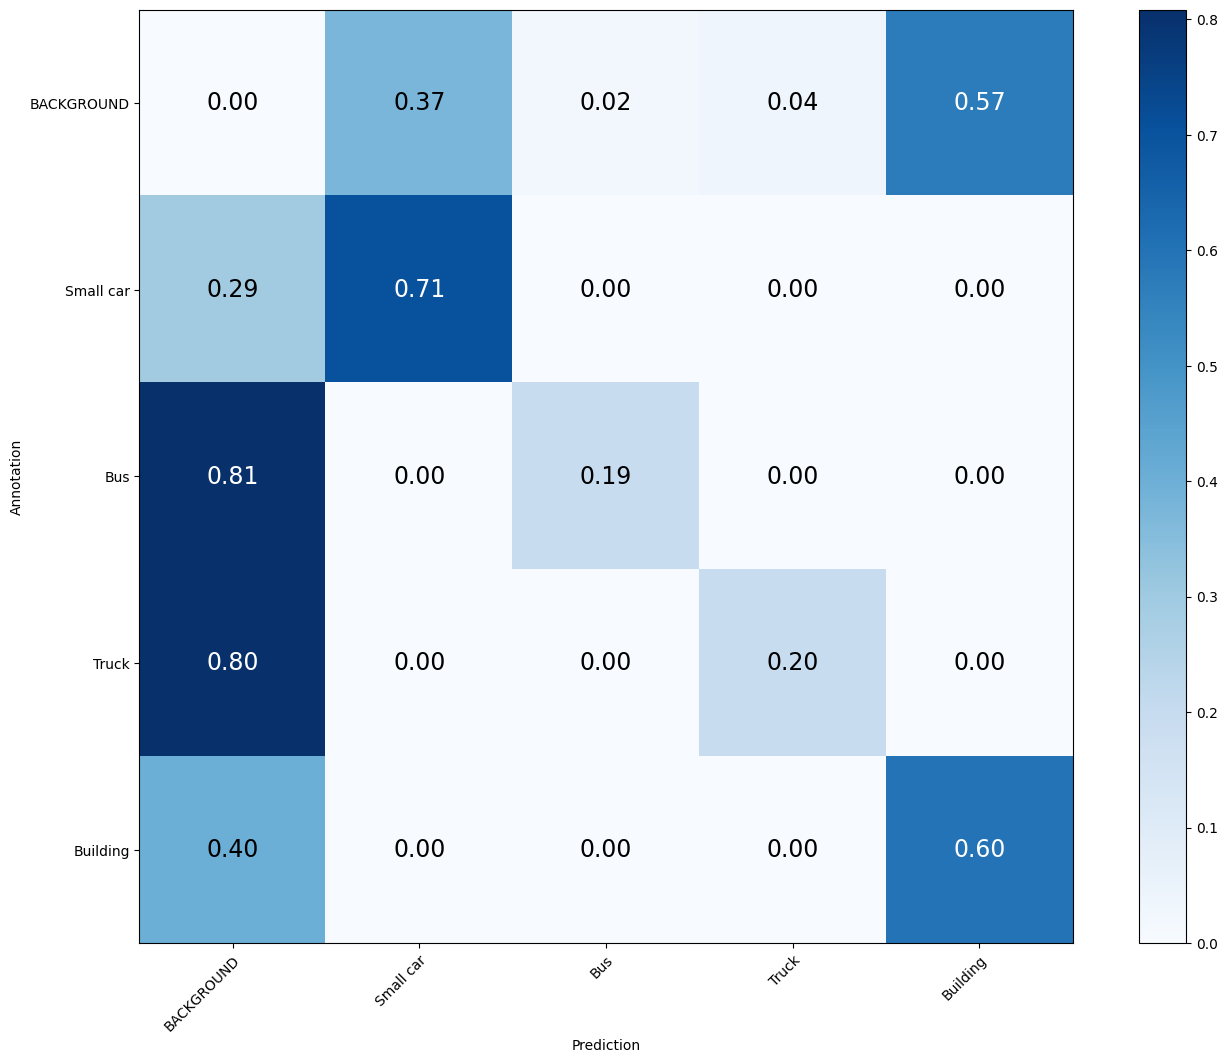

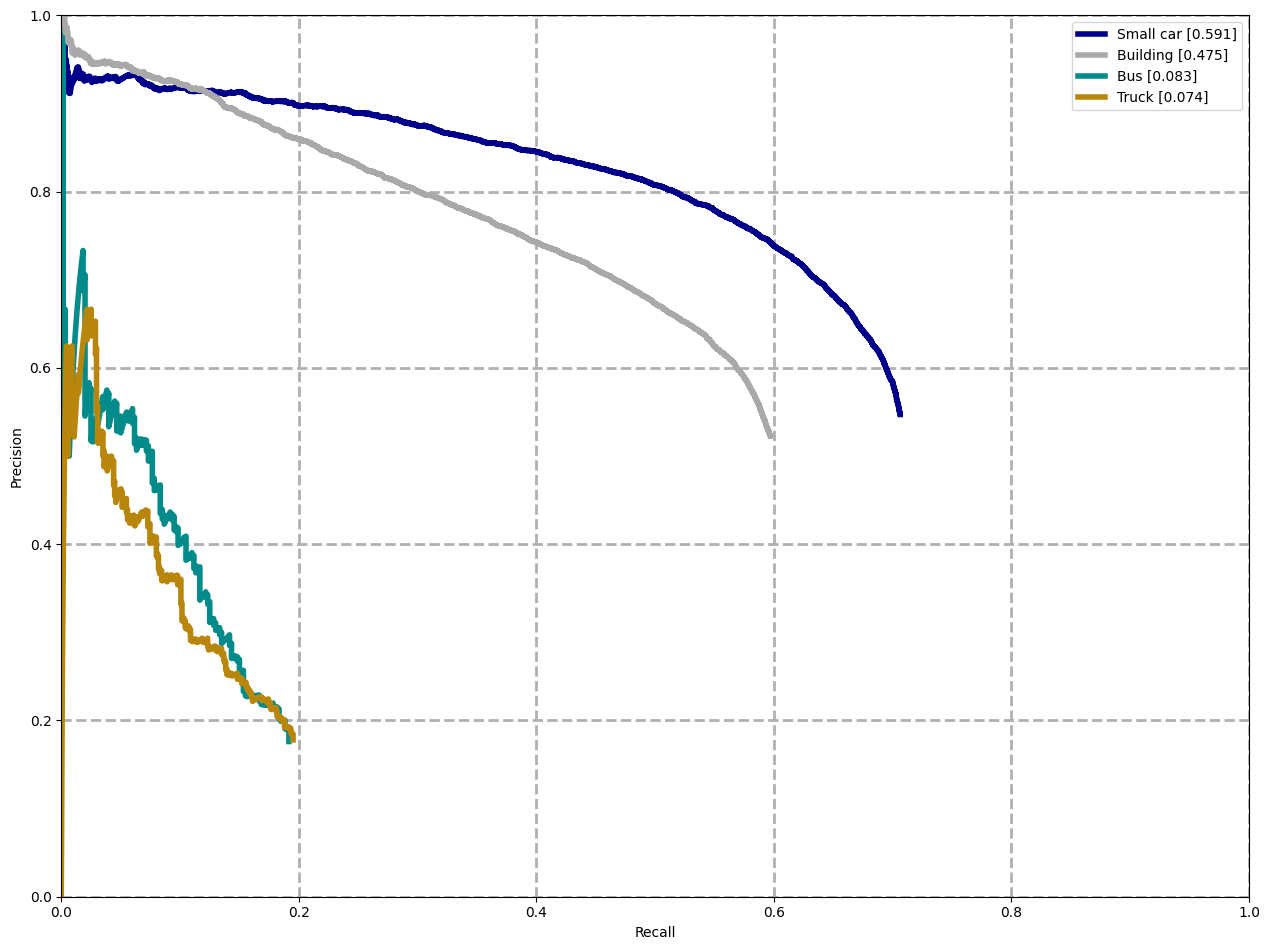

In [19]:
names = list(categories.values()).copy()
names.insert(0, default_cls)
cm = confusion_matrix(y_true, y_pred, labels=names)
print('Confusion matrix:')
print(cm)
draw_confusion_matrix(cm, names)
draw_precision_recall(precision_list, recall_list, categories)

#### Testing
Try to improve the results provided in the competition.

In [ ]:
import json
import os
import torch
import numpy as np
from tqdm import tqdm

model_path = '/kaggle/input/models-exp9/best_model.pth' 

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"✅ Cargado el mejor modelo desde: {model_path}")
else:
    model.load_state_dict(torch.load('model_rcnn.pth', map_location=device))
    print("⚠️ 'best_model' no encontrado, cargando 'model_rcnn.pth' local.")

model.eval()

categories = {0: 'Small car', 1: 'Bus', 2: 'Truck', 3: 'Building'}

test_images_path = '/kaggle/input/xview-pytorch/xview_pytorch/test/'

test_files = sorted([f for f in os.listdir(test_images_path) if f.endswith('.tif')])
print(f'🚀 Iniciando inferencia en {len(test_files)} imágenes de test...')

predictions_temp = {}

with torch.no_grad():
    for filename in tqdm(test_files):
        img_path = os.path.join('test', filename) 
        img_np = load_geoimage(img_path)
        h, w, _ = img_np.shape
        
        img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float().div(255).to(device)
        img_flipped = torch.flip(img_tensor, dims=[2]) 
        
        outputs = model([img_tensor, img_flipped])
        
        b_orig, s_orig, l_orig = outputs[0]['boxes'], outputs[0]['scores'], outputs[0]['labels']
        
        b_flip = outputs[1]['boxes']
        b_flip_corr = b_flip.clone()
        b_flip_corr[:, [0, 2]] = w - b_flip[:, [2, 0]] 
        s_flip, l_flip = outputs[1]['scores'], outputs[1]['labels']
        
        all_boxes = torch.cat([b_orig, b_flip_corr], dim=0)
        all_scores = torch.cat([s_orig, s_flip], dim=0)
        all_labels = torch.cat([l_orig, l_flip], dim=0)
        
        keep = nms(all_boxes, all_scores, iou_threshold=0.4)
        
        f_boxes = all_boxes[keep].cpu().numpy()
        f_scores = all_scores[keep].cpu().numpy()
        f_labels = all_labels[keep].cpu().numpy()

        mask = f_scores > 0.2
        predictions_temp[filename] = {
            'boxes': f_boxes[mask].astype(int),
            'scores': f_scores[mask],
            'labels': f_labels[mask]
        }


predictions_data = {"images": {}, "annotations": {}, "categories": {}}
predictions_data["categories"] = {str(k): v for k, v in categories.items()}

img_idx = 0
ann_idx = 0

for filename, pred in predictions_temp.items():
    predictions_data["images"][str(img_idx)] = {
        "image_id": filename,
        "filename": f"xview_test/{filename}", 
        "num_objects": len(pred['boxes']),
        "width": 640,
        "height": 640
    }
    
    for i in range(len(pred['boxes'])):
        cat_name = categories[int(pred['labels'][i]) - 1]
        
        predictions_data["annotations"][str(ann_idx)] = {
            "image_id": filename,
            "category_id": cat_name, 
            "bbox": pred['boxes'][i].tolist(), 
            "confidence": str(round(float(pred['scores'][i]), 8))
        }
        ann_idx += 1
    
    img_idx += 1

with open("prediction.json", "w") as outfile:
    json.dump(predictions_data, outfile)

print(f"\n✅ ¡Éxito! Archivo 'prediction.json' generado para Codabench.")
print(f"📦 Total imágenes: {img_idx} | Total objetos detectados: {ann_idx}")

✅ Cargado el mejor modelo desde: /kaggle/input/models-exp9/best_model.pth
🚀 Iniciando inferencia en 852 imágenes de test...


100%|██████████| 852/852 [02:14<00:00,  6.34it/s]



✅ ¡Éxito! Archivo 'prediction.json' generado para Codabench.
📦 Total imágenes: 852 | Total objetos detectados: 71519
